In [1]:
from cardroom.briscola.game.env import BriscolaEnv
from cardroom.briscola.game.player import BriscolaPlayer
from cardroom.briscola.agents.random import RandomAgent
from cardroom.briscola.agents.human import HumanAgent
from cardroom.briscola.agents.donatello import DonatelloAgent
from cardroom.briscola.utils.plot_mcts import recap_info_node, plot_info_node

from IPython.display import clear_output

pygame 2.6.1 (SDL 2.28.4, Python 3.13.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


Game setup

In [2]:
SIMULATIONS = 1000 # how many simulations MCTS runs

render_mode = "text"

human = HumanAgent(input_mode=render_mode)
random = RandomAgent()
donatello = DonatelloAgent(simulations = SIMULATIONS)
names = ["Donatello", "Random"]

env = BriscolaEnv(names, render_mode=render_mode)
if render_mode == "pygame":
    human.set_pygame_action_retriever(env.pygame)
agents = [donatello, random]

New game starting!
Players: ['Donatello', 'Random']
Random to start.
Briscola: Bastoni - Spy: K of Bastoni


[0, 0]
---TURN 1---
Random plays 4 of Spade.
Player to move: 0
Total visits: 1000
Action |      N |      Q
----------------------
     2 |    759 |   0.19
     1 |    135 |  -0.09
     0 |    106 |  -0.17


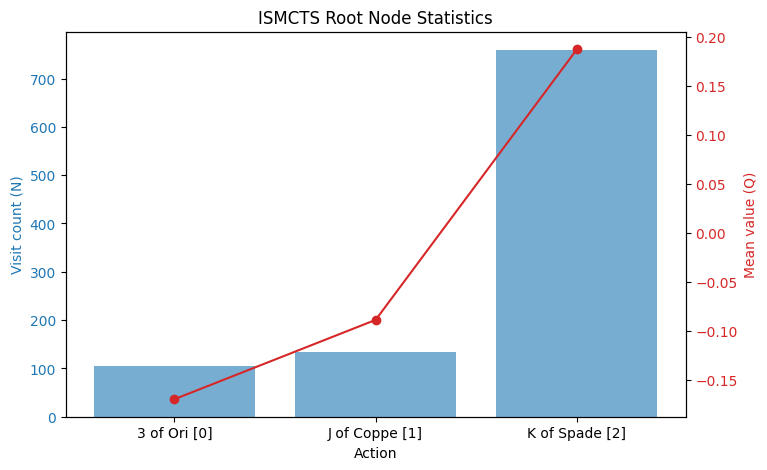

In [3]:
while not env.done:
    player_id = env.current_player_id
    player = env.players[player_id]
    agent = agents[player_id]
    if isinstance(agent, DonatelloAgent): # ugly. should be the same call for all agents
        obs = env.get_observation()
        # card_on_table = obs["card_on_table"][0].__str__() if len(obs["cards_on_table"]) > 0 else None
        action, root = agent.select_action(env.get_observation(), env.clone_from_observation(), return_root=True)
        card_names = [env.get_observation()["hand"][i].__str__() + f" [{i}]" for i in range(len(env.get_observation()["hand"]))]

        print(recap_info_node(root, top_k = 3))
        plot_info_node(root, card_names)

        if input("Press enter to continue, q to quit: ") == "q":
            break
        else:
            clear_output()
    else:
        action = agent.select_action(env.get_observation())
    env.step(action)